# 📘Домашнє завдання №12 Дерева рішень

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW12

## 📌 Завдання 1
Використайте датасет Titanic:  
https://www.kaggle.com/datasets/yasserh/titanic-dataset  

- Завантажте дані  
- Обробіть пропущені значення  
- Закодуйте категоріальні змінні (наприклад, `Sex`, `Embarked`)  

---

## 📌 Завдання 2
Побудуйте модель класифікації:

- Натренуйте `DecisionTreeClassifier`  
- Зробіть прогноз на тестових даних  
- Обчисліть метрики:
  - accuracy  
  - precision  
  - recall  

👉 Проаналізуйте отримані результати

---

## 📌 Завдання 3
Візуалізуйте дерево рішень:

- Виведіть структуру дерева (`plot_tree` або аналог)  
- Проаналізуйте:
  - які ознаки використовуються найчастіше  
  - які правила формуються  

---

## 📌 Завдання 4
Використайте датасет Fish Market:  
https://www.kaggle.com/datasets/vipullrathod/fish-market  

- Побудуйте модель `DecisionTreeRegressor`  
- Натренуйте модель для прогнозування (наприклад, `Weight`)  
- Обчисліть метрики:
  - MSE  
  - R²  

---

## 📌 Завдання 5
Оптимізація моделі:

- Використайте `GridSearchCV` для підбору гіперпараметрів (наприклад: `max_depth`, `min_samples_leaf`)  
- Знайдіть найкращу модель  
- Порівняйте метрики з результатами з **Завдання 4**  

👉 Зробіть висновок:
- чи покращилась модель після підбору параметрів?

In [1]:
# Synchronization with remote source

import shutil
from pathlib import Path

# Input data
git_project_url = "https://github.com/BogdanPinchuk/DataScience-PBY_HW12.git"
main_file_name = "Bohdan_Pinchuk_DS_HW12.ipynb"

# Solution

# upload all files
current_path = !pwd
current_path = current_path[0]
parent_path = !dirname "$current_path"
parent_path = parent_path[0]
temp_path = f"{parent_path}/temp"

# Clone data
!rm -rf "$temp_path"
!git clone "$git_project_url" "$temp_path"

source = Path(temp_path)
destination = Path(current_path)
exclude = {main_file_name, ".git", ".idea"}

for item in source.iterdir():
    if item.name in exclude:
        continue

    target = destination / item.name
    if item.is_dir():
        shutil.copytree(item, target, dirs_exist_ok=True)
    else:
        shutil.copy2(item, target)

# Clean temp folder
!rm -rf "$temp_path"

Cloning into '/Users/bohdanpinchuk/Documents/Data Science/Development/Data_Science/Practical_tasks/Homework_12/temp'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 41 (delta 12), reused 35 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 394.85 KiB | 3.08 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [2]:
# Download data (to cover the case when the data aren't accessible)

# !pip install kagglehub[pandas-datasets]
# !pip install ipywidgets
# !pip install --upgrade nbformat
# !pip install jinja2

import sqlite3
import kagglehub
import pandas as pd
from pandas import DataFrame
from kagglehub import KaggleDatasetAdapter
from pathlib import Path

# Input data
db_file_name = "store_hw12.db"


# Solution
def download_and_extract_from_kagglehub(ds_path: str, ds_file_name: str) -> DataFrame | None:
    """
    Download and extract data from kagglehub
    :param ds_path: path to kaggle dataset
    :param ds_file_name: name of kaggle dataset
    :return: DataFrame or None
    """
    ds_name = ds_path.split("/")[-1].replace('-', '_')

    # Note: to handle error: "SSL: CERTIFICATE_VERIFY_FAILED" or no connection to the server
    try:
        # for testing
        # raise Exception

        ds_data = kagglehub.dataset_load(
            KaggleDatasetAdapter.PANDAS,
            ds_path,
            ds_file_name,
        )

        file_path = Path(db_file_name)

        # Use only one time to initialize/update data (at first time)
        if not file_path.exists():
            conn = sqlite3.connect(db_file_name)
            ds_data.to_sql(ds_name, conn, if_exists="replace", index=False)
            conn.close()
    except Exception:
        conn = sqlite3.connect(db_file_name)
        ds_data = pd.read_sql(f"SELECT * FROM {ds_name}", conn)
        conn.close()

    return ds_data


In [3]:
## Отримання даних

# Solution
titanic_dataset = download_and_extract_from_kagglehub("yasserh/titanic-dataset", "Titanic-Dataset.csv")
fish_market = download_and_extract_from_kagglehub("vipullrathod/fish-market", "Fish.csv")

# Print result
# display(titanic_dataset, fish_market)


## Рішення 1
Використайте датасет Titanic:
- Завантажте дані
- Обробіть пропущені значення
- Закодуйте категоріальні змінні (наприклад, `Sex`, `Embarked`)

In [4]:
# Аналіз даних

import numpy as np
import pandas as pd
import apps.main as mn

# Input data
data_set = titanic_dataset
n_columns = data_set.columns.size
n_rows = data_set.index.size

# Solution
columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = mn.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')
rp.print_pd_report("Параметри таблиці до обробки")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))

# Print results
display(titanic_dataset)

Attribute,Result
Кількість рядків,891
Кількість об’єктів у датасеті,891
Кількість стовпців,12
Кількість числових ознак,7
Кількість категоріальних ознак,5
Пропущені значення,є


,count
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
# Обробка даних

import numpy as np
import pandas as pd
import apps.main as mn

# Input data
ages_col_name = "Age"
fares_col_name = "Fare"
sibsp_col_name = "SibSp"
parch_col_name = "Parch"
family_col_name = "Family"
fill_col_list = ["Age", "Embarked"]
drop_col_list = ["PassengerId", "Name", "Ticket", "Cabin"]

# Solution
titanic_dataset.drop(columns=drop_col_list, inplace=True)

# Заповнення пропусків
for col_name in fill_col_list:
    most_often_value = titanic_dataset[col_name].mode()[0]
    titanic_dataset[col_name] = titanic_dataset[col_name].fillna(most_often_value)

# Корегування даних
titanic_dataset[ages_col_name] = titanic_dataset[ages_col_name].round().astype(int)
titanic_dataset[fares_col_name] = titanic_dataset[fares_col_name].round(2).astype(float)

# Заміна даних і очищення
titanic_dataset[family_col_name] = titanic_dataset.apply(
    lambda df_row: df_row[sibsp_col_name] + df_row[parch_col_name] + 1, axis=1)
titanic_dataset.drop(columns=[sibsp_col_name, parch_col_name], inplace=True)

data_set = titanic_dataset
n_columns = data_set.columns.size
n_rows = data_set.index.size

columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = mn.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')
rp.print_pd_report("Параметри таблиці після обробки")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))

# Print results
display(titanic_dataset)

Attribute,Result
Кількість рядків,891
Кількість об’єктів у датасеті,891
Кількість стовпців,7
Кількість числових ознак,5
Кількість категоріальних ознак,2
Пропущені значення,немає


,Survived,Pclass,Sex,Age,Fare,Embarked,Family
0,0,3,male,22,7.25,S,2
1,1,1,female,38,71.28,C,2
2,1,3,female,26,7.92,S,1
3,1,1,female,35,53.10,S,2
4,0,3,male,35,8.05,S,1
...,...,...,...,...,...,...,...
886,0,2,male,27,13.00,S,1
887,1,1,female,19,30.00,S,1
888,0,3,female,24,23.45,S,4
889,1,1,male,26,30.00,C,1


In [6]:
# Обробка даних

import numpy as np
import pandas as pd
import apps.main as mn
from sklearn.preprocessing import OneHotEncoder

# Input data
cat_col_list = ["Sex", "Embarked"]

# Solution
for col_name in cat_col_list:
    ohe = OneHotEncoder(sparse_output=False)
    encoded_cols = ohe.fit_transform(titanic_dataset[[col_name]]).astype(int)
    new_col_names = ohe.get_feature_names_out([col_name])

    for col_id, new_col_name in enumerate(new_col_names):
        titanic_dataset[new_col_name] = encoded_cols[:, col_id]

    titanic_dataset.drop(columns=[col_name], inplace=True)

data_set = titanic_dataset
n_columns = data_set.columns.size
n_rows = data_set.index.size

columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = mn.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')
rp.print_pd_report("Параметри таблиці після кодування")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))

# Print results
display(columns_df.style.set_caption("Назви колонок").hide(axis='index'))
display(types_df.style.set_caption("Типи даних"))
display(titanic_dataset)

Attribute,Result
Кількість рядків,891
Кількість об’єктів у датасеті,891
Кількість стовпців,10
Кількість числових ознак,10
Кількість категоріальних ознак,0
Пропущені значення,немає


Columns
Survived
Pclass
Age
Fare
Family
Sex_female
Sex_male
Embarked_C
Embarked_Q
Embarked_S


,Types
Survived,int64
Pclass,int64
Age,int64
Fare,float64
Family,int64
Sex_female,int64
Sex_male,int64
Embarked_C,int64
Embarked_Q,int64
Embarked_S,int64


,Survived,Pclass,Age,Fare,Family,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22,7.25,2,0,1,0,0,1
1,1,1,38,71.28,2,1,0,1,0,0
2,1,3,26,7.92,1,1,0,0,0,1
3,1,1,35,53.10,2,1,0,0,0,1
4,0,3,35,8.05,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27,13.00,1,0,1,0,0,1
887,1,1,19,30.00,1,1,0,0,0,1
888,0,3,24,23.45,4,1,0,0,0,1
889,1,1,26,30.00,1,0,1,1,0,0


## Рішення 2
Побудуйте модель класифікації:

- Натренуйте `DecisionTreeClassifier`
- Зробіть прогноз на тестових даних
- Обчисліть метрики:
  - accuracy
  - precision
  - recall

Проаналізуйте отримані результати

In [7]:
import gc
import pandas as pd
from sklearn.model_selection import train_test_split

# Input data
target_value = "Survived"
test_ratio = 0.2
rng_seed = 42

# Solution
X_data = titanic_dataset.drop(columns=[target_value])
Y_data = titanic_dataset[target_value]

del titanic_dataset

X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size=test_ratio,
                                                    random_state=rng_seed, shuffle=True)

# Print results
display(pd.concat([
    Y_train.value_counts(),
    Y_train.value_counts(normalize=True)
], axis=1).style.set_caption("Вибірка для навчання"))
display(pd.concat([
    Y_test.value_counts(),
    Y_test.value_counts(normalize=True)
], axis=1).style.set_caption("Вибірка для тестування"))

# Clean
gc.collect()

,count,proportion
Survived,,
0,444,0.623596
1,268,0.376404


,count,proportion
Survived,,
0,105,0.586592
1,74,0.413408


80

In [8]:
import joblib
import pandas as pd
import apps.main as mn
from pathlib import Path
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

# Input data
rng_seed = 42
load_model = True
model_file_name = "resources/titanic-dataset.model"
file_path = Path(model_file_name)


# Solution
def calc_metrics(y_test, y_pred):
    rp = mn.Reporter()
    rp.tolerance = 4

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    rp.add_item("Confusion Matrix", rp.format_matrix(cm))
    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    rp.add_item("Accuracy\n(Точність)", rp.format_value(accuracy))
    # Precision
    precision = precision_score(y_test, y_pred)
    rp.add_item("Precision\n(Влучність)", rp.format_value(precision))
    # Recall
    recall = recall_score(y_test, y_pred)
    rp.add_item("Recall\n(Повнота)", rp.format_value(recall))
    # F1-score
    f1 = f1_score(y_test, y_pred)
    rp.add_item("F1-score", rp.format_value(f1))

    # Print results
    rp.print_pd_report(f"Метрики")


# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=5,
        min_samples_leaf=10,
        random_state=rng_seed
    )
    # save model
    joblib.dump(model, model_file_name)

model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

# Print results
calc_metrics(Y_test, Y_pred)
print(classification_report(Y_test, Y_pred))


loaded


Attribute,Result
Confusion Matrix,[[92 13] [19 55]]
Accuracy (Точність),0.8212
Precision (Влучність),0.8088
Recall (Повнота),0.7432
F1-score,0.7746


              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



Із документації для "Confusion Matrix":

Колонка 1 | Колонка 2
--- | ---
true negatives :math:`C_{0,0}` | false positives :math:`C_{0,1}`
false negatives :math:`C_{1,0}` | true positives :math:`C_{1,1}`

Матриця:

№1 | №2
--|--
TN | FP
FN | TP

* TN — фактично/реально 0, передбачено/вгадано 0; (Правильно вказана смерть)
* FP — фактично/реально 0, передбачено/вгадано 1; (Хибна надія на виживання)
* FN — фактично/реально 1, передбачено/вгадано 0; (Помилково вказана смерть)
* TP — фактично/реально 1, передбачено/вгадано 1; (Правильно сповіщено про те що вижив)

- Accuracy (Точність) `[(TP + TN)/(Total)]`: Загальний відсоток правильних відповідей.
- Precision (Влучність) `[TP/(TP + FP)]`: Наскільки ми можемо довіряти моделі, коли вона каже "вижив".
- Recall (Повнота) `[TP/(TP + FN)]`: Який відсоток усіх, хто вижив, ми реально знайшли.

Висновок. [Характеристика: Gini Impurity] Аналізуючи тестові вибірки та результати звітів, можна сказати, що модель краща за випадкове вгадування або якщо всім поставили одне зі значень "0" або "1". Аналізуючи матрицю помилок, маємо, що спрогнозовано правильно 92 померлих і 55, що вижили, але 13 сказано, що померли, хоча вони вижили, і 19, що вижили, хоча померли.

## Рішення 3
Візуалізуйте дерево рішень:

- Виведіть структуру дерева (`plot_tree` або аналог)
- Проаналізуйте:
  - які ознаки використовуються найчастіше
  - які правила формуються

In [9]:
from ete4 import Tree
from sklearn.tree import _tree

# Input data
tree_data = model.tree_
feature_names = X_data.columns.to_list()
class_names = ['died', 'survived']


# Solution
def sklearn_to_ete4(tree: _tree.Tree, features: list, classes: list, node_id: int = 0) -> str:
    if tree.children_left[node_id] == _tree.TREE_LEAF or tree.children_right[node_id] == _tree.TREE_LEAF:
        values = tree.value[node_id][0]
        class_id = values.argmax()
        class_name = classes[class_id]
        return str(class_name)

    feature_id = tree.feature[node_id]
    feature_name = features[feature_id]

    left_child_id = tree.children_left[node_id]
    left_child = sklearn_to_ete4(tree, features, classes, left_child_id)
    right_child_id = tree.children_right[node_id]
    right_child = sklearn_to_ete4(tree, features, classes, right_child_id)

    return f"{feature_name},({left_child},{right_child})"


decision_tree = Tree(f"({sklearn_to_ete4(tree_data, feature_names, class_names)});")

# Print results
print(decision_tree)

 ╭╴Sex_female
 │ ╭╴Age
 │ │ ╭╴Family
 │ │ ├─┬╴survived
 │ │ │ ╰╴died
 │ │ ├╴Pclass
 │ ├─┤ ╭╴Age
─┤ │ │ │ ╭╴Fare
 │ │ │ │ ├─┬╴died
 │ │ │ ├─┤ ╰╴died
 │ │ │ │ ├╴Age
 │ │ ╰─┤ ╰─┬╴survived
 │ │   │   ╰╴died
 │ │   ├╴Age
 ╰─┤   │ ╭╴Age
   │   │ ├─┬╴died
   │   ╰─┤ ╰╴died
   │     ├╴Fare
   │     ╰─┬╴died
   │       ╰╴died
   ├╴Pclass
   │ ╭╴Age
   │ │ ╭╴Embarked_S
   │ │ │ ╭╴survived
   │ │ ├─┼╴Age
   │ ├─┤ ╰─┬╴survived
   │ │ │   ╰╴survived
   │ │ ├╴Age
   ╰─┤ ╰─┬╴survived
     │   ╰╴survived
     ├╴Fare
     │ ╭╴Embarked_S
     │ │ ╭╴Fare
     │ │ ├─┬╴survived
     │ ├─┤ ╰╴survived
     ╰─┤ ├╴Fare
       │ ╰─┬╴died
       │   ╰╴survived
       ├╴Family
       ╰─┬╴died
         ╰╴died


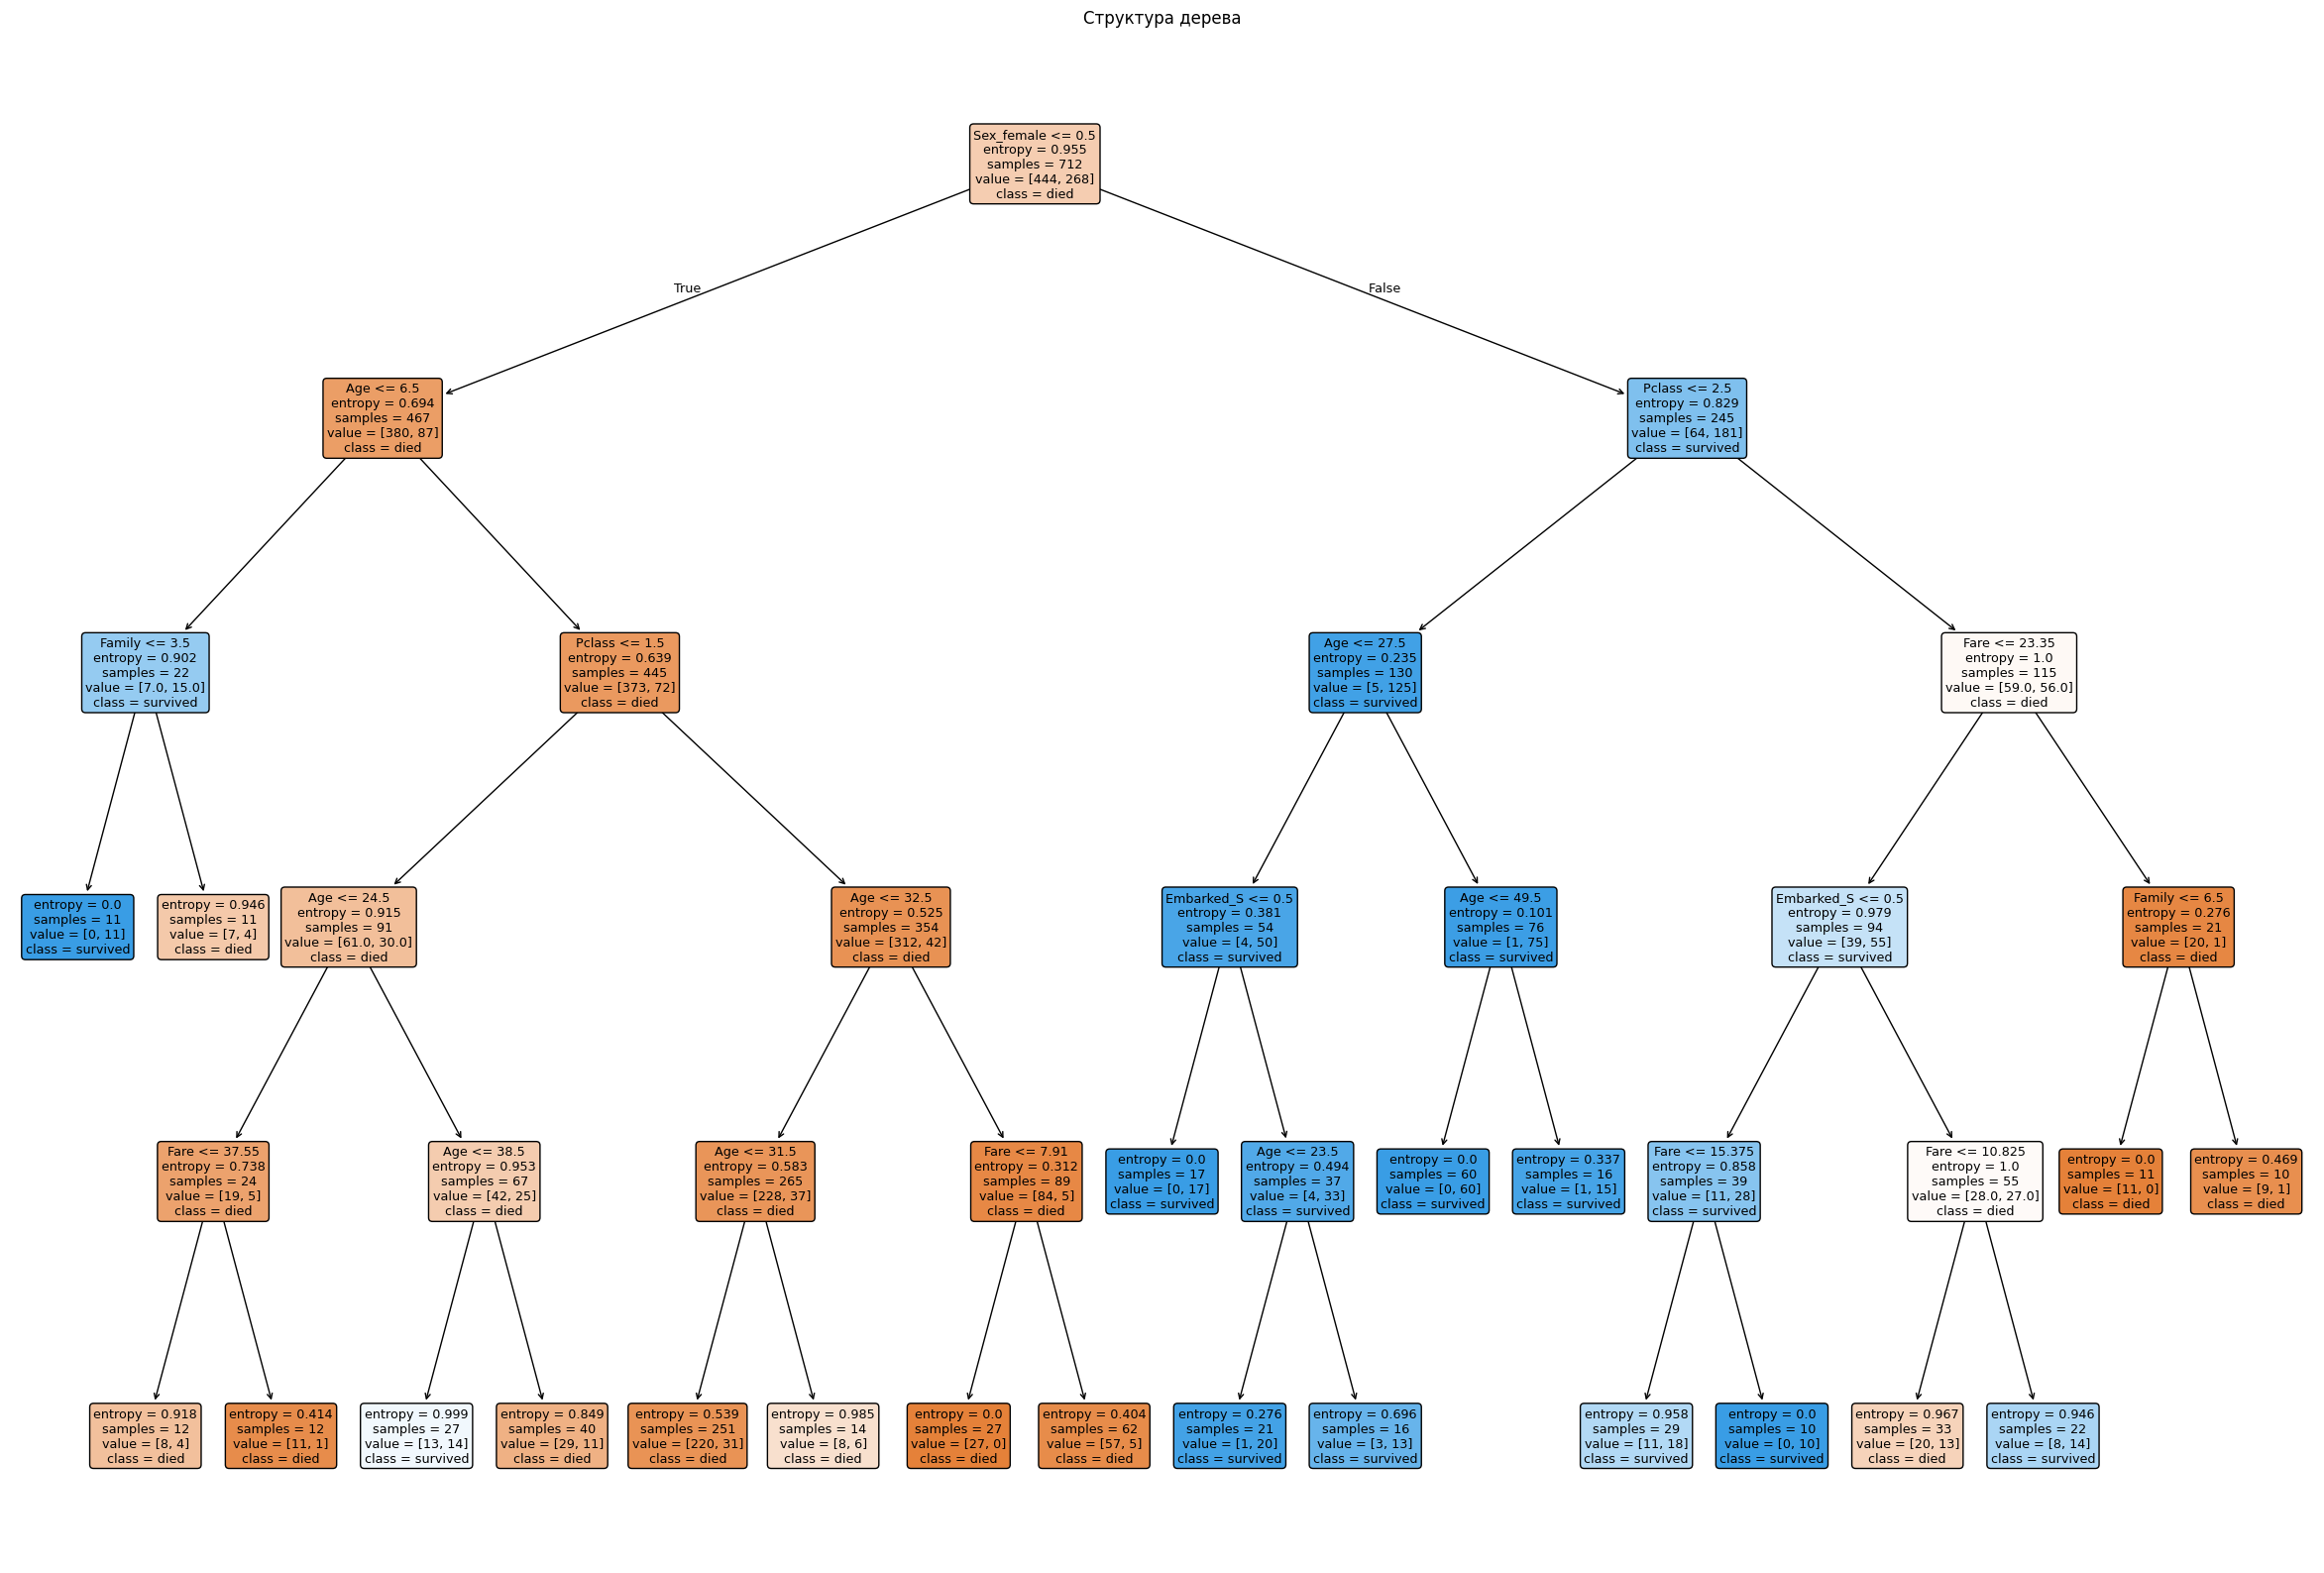

In [10]:
# Graphic results

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Input data
class_names = ['died', 'survived']

# Solution
_, ax = plt.subplots(figsize=(30, 20))

plot_tree(model, ax=ax, filled=True, rounded=True, feature_names=X_data.columns, class_names=class_names)

ax.set_title("Структура дерева", pad=10, loc='center', color='black')

plt.show()

Висновок. Ознаки за частотою використання: Вік (6) -> Fare (5) -> Family (2) і Pclass (2). У корені дерева йде поділ за статтю (жінки в пріоритеті), далі частіше звертається увага на багатство (багаті в пріоритеті) і потім на вік.